In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.inspection import DecisionBoundaryDisplay

#Part A – Dataset A (Linearly Separable)

In [ ]:
# 1. Generate Dataset A
X, y = make_blobs(n_samples=1000, centers=2, n_features=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 2. Custom Perceptron Implementation
class CustomPerceptron:
    def __init__(self, lr=0.01, n_iter=50):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        self.errors_ = []
        self.w_ = np.zeros(1 + X.shape[1])
        y_ = np.where(y == 0, -1, 1)  # convert labels to {-1,1}

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y_):
                update = self.lr * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

In [ ]:
# Train custom perceptron
cp = CustomPerceptron(lr=0.01, n_iter=20)
cp.fit(X_train, y_train)

/tmp/ipython-input-931164165.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


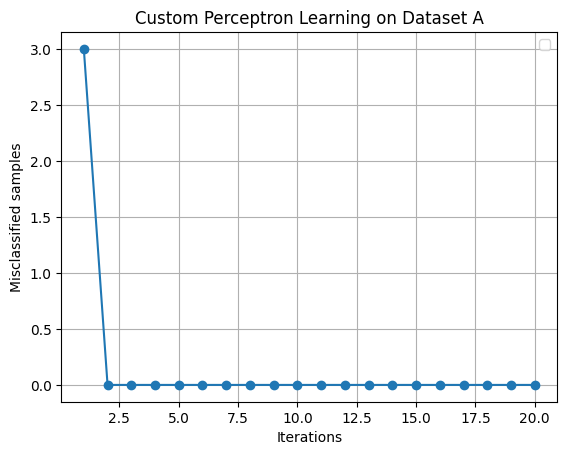

In [ ]:
# Plot misclassifications per iteration
plt.plot(range(1, len(cp.errors_)+1), cp.errors_, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Misclassified samples")
plt.title("Custom Perceptron Learning on Dataset A")
plt.legend()
plt.grid(True)
plt.show()

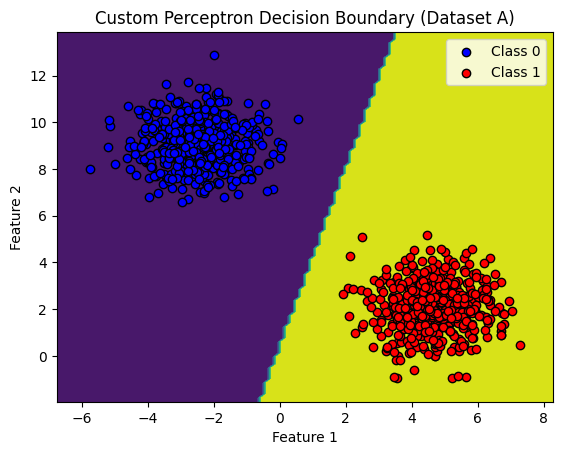

In [ ]:
# Decision Boundary Visualization

disp = DecisionBoundaryDisplay.from_estimator(cp, X, response_method="predict")
# Scatter with class-specific legends
scatter0 = plt.scatter(X[y==0, 0], X[y==0, 1], color="blue", edgecolor='k', label="Class 0")
scatter1 = plt.scatter(X[y==1, 0], X[y==1, 1], color="red", edgecolor='k', label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Custom Perceptron Decision Boundary (Dataset A)")
plt.legend(handles=[scatter0, scatter1])
plt.show()

In [ ]:
# Predictions and metrics
y_pred_custom = np.where(cp.predict(X_test) == -1, 0, 1)
print("Custom Perceptron (Dataset A):")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))

Custom Perceptron (Dataset A):
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [ ]:
# Scikit-learn Perceptron
sk_perc = Perceptron(max_iter=1000, random_state=42)
sk_perc.fit(X_train, y_train)
y_pred_sk = sk_perc.predict(X_test)

In [ ]:
print("\nSklearn Perceptron (Dataset A):")
print("Accuracy:", accuracy_score(y_test, y_pred_sk))
print("Precision:", precision_score(y_test, y_pred_sk))
print("Recall:", recall_score(y_test, y_pred_sk))


Sklearn Perceptron (Dataset A):
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


#Part B – Non-Linearly Separable Dataset (Dataset B)

In [ ]:
from sklearn.datasets import make_classification

# 1. Generate Dataset B
Xb, yb = make_classification(n_samples=1000, n_features=2, n_classes=2,
                             n_clusters_per_class=1, n_redundant=0,
                             n_informative=2, flip_y=0.2, random_state=42)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.2, random_state=42)


In [ ]:
# Train custom perceptron on Dataset B
cp_b = CustomPerceptron(lr=0.01, n_iter=20)
cp_b.fit(Xb_train, yb_train)


/tmp/ipython-input-797530214.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


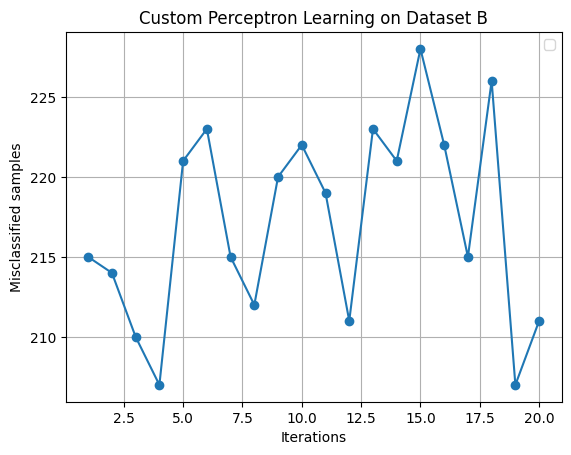

In [ ]:
# Plot misclassifications
plt.plot(range(1, len(cp_b.errors_)+1), cp_b.errors_, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Misclassified samples")
plt.title("Custom Perceptron Learning on Dataset B")
plt.legend()
plt.grid(True)
plt.show()

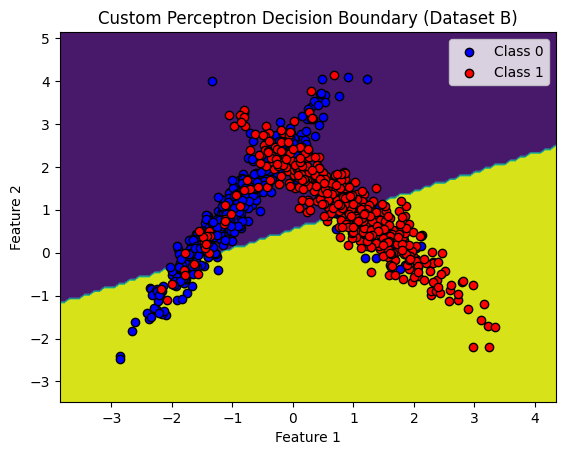

In [ ]:
# Decision boundary
disp = DecisionBoundaryDisplay.from_estimator(cp_b, Xb, response_method="predict")
scatter0 = plt.scatter(Xb[yb==0, 0], Xb[yb==0, 1], color="blue", edgecolor='k', label="Class 0")
scatter1 = plt.scatter(Xb[yb==1, 0], Xb[yb==1, 1], color="red", edgecolor='k', label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Custom Perceptron Decision Boundary (Dataset B)")
plt.legend(handles=[scatter0, scatter1])
plt.show()

In [ ]:
# Performance metrics
y_pred_b_custom = np.where(cp_b.predict(Xb_test) == -1, 0, 1)
print("Custom Perceptron (Dataset B):")
print("Accuracy:", accuracy_score(yb_test, y_pred_b_custom))
print("Precision:", precision_score(yb_test, y_pred_b_custom))
print("Recall:", recall_score(yb_test, y_pred_b_custom))

Custom Perceptron (Dataset B):
Accuracy: 0.665
Precision: 0.7457627118644068
Recall: 0.4583333333333333


In [ ]:
# Sklearn Perceptron
sk_perc_b = Perceptron(max_iter=1000, random_state=42)
sk_perc_b.fit(Xb_train, yb_train)
y_pred_b_sk = sk_perc_b.predict(Xb_test)

In [ ]:
print("\nSklearn Perceptron (Dataset B):")
print("Accuracy:", accuracy_score(yb_test, y_pred_b_sk))
print("Precision:", precision_score(yb_test, y_pred_b_sk))
print("Recall:", recall_score(yb_test, y_pred_b_sk))


Sklearn Perceptron (Dataset B):
Accuracy: 0.58
Precision: 0.536144578313253
Recall: 0.9270833333333334


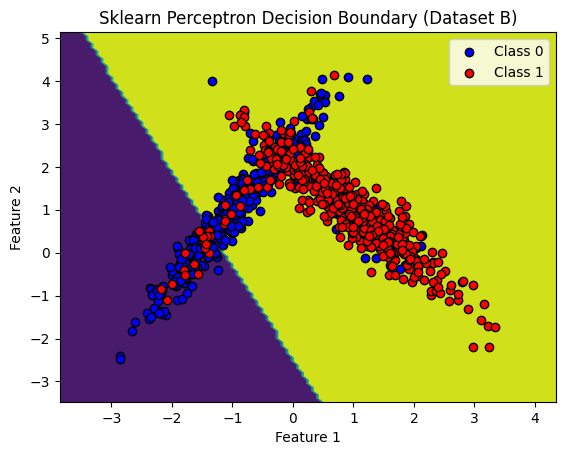

In [ ]:
# Decision boundary
disp = DecisionBoundaryDisplay.from_estimator(sk_perc_b, Xb, response_method="predict")
scatter0 = plt.scatter(Xb[yb==0, 0], Xb[yb==0, 1], color="blue", edgecolor='k', label="Class 0")
scatter1 = plt.scatter(Xb[yb==1, 0], Xb[yb==1, 1], color="red", edgecolor='k', label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Sklearn Perceptron Decision Boundary (Dataset B)")
plt.legend(handles=[scatter0, scatter1])
plt.show()

#Part C – Feedforward Neural Network (Dataset B)

In [ ]:
# Simple Feedforward Neural Network (1 hidden layer) from scratch

class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def fit(self, X, y):

        y = y.reshape(-1, 1)
        for _ in range(self.epochs):
            # Forward pass
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.sigmoid(z1)
            z2 = np.dot(a1, self.W2) + self.b2
            a2 = self.sigmoid(z2)

            # Backpropagation
            dz2 = a2 - y
            dW2 = np.dot(a1.T, dz2) / X.shape[0]
            db2 = np.sum(dz2, axis=0, keepdims=True) / X.shape[0]
            dz1 = np.dot(dz2, self.W2.T) * self.sigmoid_derivative(a1)
            dW1 = np.dot(X.T, dz1) / X.shape[0]
            db1 = np.sum(dz1, axis=0, keepdims=True) / X.shape[0]

            # Update weights
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

        # return self

    def predict(self, X):
        a1 = self.sigmoid(np.dot(X, self.W1) + self.b1)
        a2 = self.sigmoid(np.dot(a1, self.W2) + self.b2)
        return (a2 > 0.5).astype(int).flatten()


In [ ]:
# Train Simple NN
nn = SimpleNN(input_size=2, hidden_size=5, output_size=1, lr=0.1, epochs=5000)
nn.fit(Xb_train, yb_train)

In [ ]:
# Predictions
y_pred_nn = nn.predict(Xb_test)

print("\nCustom Neural Network (Dataset B):")
print("Accuracy:", accuracy_score(yb_test, y_pred_nn))
print("Precision:", precision_score(yb_test, y_pred_nn))
print("Recall:", recall_score(yb_test, y_pred_nn))



Custom Neural Network (Dataset B):
Accuracy: 0.855
Precision: 0.8850574712643678
Recall: 0.8020833333333334


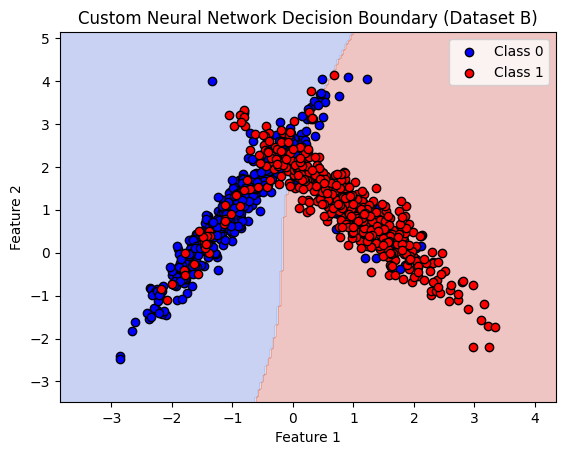

In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Create grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predictions over grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contour
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot samples
    scatter0 = plt.scatter(X[y==0, 0], X[y==0, 1], color="blue", edgecolor='k', label="Class 0")
    scatter1 = plt.scatter(X[y==1, 0], X[y==1, 1], color="red", edgecolor='k', label="Class 1")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend(handles=[scatter0, scatter1])
    plt.show()

# Use for custom NN
plot_decision_boundary(nn, Xb, yb, title="Custom Neural Network Decision Boundary (Dataset B)")

In [ ]:
# # Decision Boundary with class-specific legends
# plt.figure(figsize=(6,4))
# disp = DecisionBoundaryDisplay.from_estimator(nn, Xb, response_method="predict", alpha=0.3)

# scatter0 = plt.scatter(Xb[yb==0, 0], Xb[yb==0, 1], color="blue", edgecolor='k', label="Class 0")
# scatter1 = plt.scatter(Xb[yb==1, 0], Xb[yb==1, 1], color="red", edgecolor='k', label="Class 1")

# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.title("Custom Neural Network Decision Boundary (Dataset B)")
# plt.legend(handles=[scatter0, scatter1])
# plt.show()

In [ ]:
# Compare with Sklearn MLP
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(5,), max_iter=2000, random_state=42)
mlp.fit(Xb_train, yb_train)
y_pred_mlp = mlp.predict(Xb_test)

In [ ]:
print("\nSklearn MLP (Dataset B):")
print("Accuracy:", accuracy_score(yb_test, y_pred_mlp))
print("Precision:", precision_score(yb_test, y_pred_mlp))
print("Recall:", recall_score(yb_test, y_pred_mlp))


Sklearn MLP (Dataset B):
Accuracy: 0.865
Precision: 0.9058823529411765
Recall: 0.8020833333333334


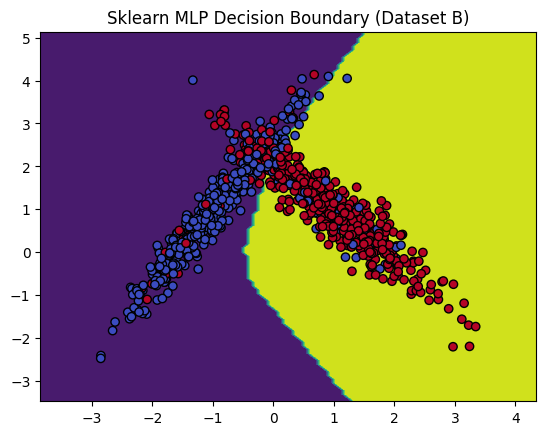

In [ ]:
# Decision boundary

disp = DecisionBoundaryDisplay.from_estimator(mlp, Xb, response_method="predict")
plt.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title("Sklearn MLP Decision Boundary (Dataset B)")
plt.show()

#Lab 6 Assignment – Feedforward Neural Network on Insurance Premium Dataset

##Dataset: [Insurance Premium (OpenML ID 43463](https://www.openml.org/search?type=data&status=active&id=43463)

##Total Marks: 20

##Assignment Instructions & Questions

###Q1. Load and Inspect Dataset (2 marks)

Load the Insurance Premium dataset from OpenML. Check for: Missing features and duplicate entries.

###Q2. Dataset Splitting (2 marks)

Split the dataset into train (70%), validation (15%), and test (15%).

###Q3. Feature Preprocessing (2 marks)

Perform feature scaling (e.g., MinMax scaling or Standardization) so all numerical features are in the same range. Encode categorical features like region using One-Hot Encoding.

###Q4. Implement Feedforward Neural Network (5 marks)

1. Implement a feedforward neural network from scratch (NumPy).
2. Use number of hidden layers and neurons per layer as hyperparameters.
3. Use MSE as the loss function.
4. Train using Mini-batch Gradient Descent.
5. Choose a suitable learning rate and batch size.

###Q5. Hyperparameter Tuning (2 marks)

Tune the number of hidden layers and neurons per layer on the validation set.
Try the following combinations:
1. Neurons in a layer: [32,64,128]
2. Number of hidden layers: [2,3]

Pick learning rate and batch size as per your choice.

###Q6. Training & Validation Curves (2 marks)

For the best hyperparameters, plot the training and validation loss vs. epochs.

###Q7. Model Evaluation – Custom NN (2 marks)

1. On the test set, report MSE and R² Score, round predictions to nearest integers.

2. Show a scatter plot of predictions vs ground truth targets.

###Q8. Sklearn MLPRegressor (3 marks)

1. Train MLPRegressor with the same hyperparameters and report test set performance
(MSE, R² Score).
2. Compare its performace with custom NN.
3. Show scatter plot of predictions vs ground truths.